## Visualization of Plant Connectivity

In [3]:
import os
import sys
import numpy as np
import pickle
import pandas as pd

sys.path.append('../../scripts')
from utils import average_across_days, average_across_days_phiid

metric = 'PhiID'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

ecosystem = 'JardinFleuris'
# NOTE: do NOT change the info file — just alias seasons -> sites here
from JardinFleuris_info import seasons, plant_common_names
sites = seasons  # treat each series as a site
list_sites = list(sites.keys())

df_all_sites = []
for SITE in list_sites:
    try:
        with open(f'../../data/processed/plant_data_{ecosystem}/{sites[SITE]}/connectivity_results_{metric}_tau100_kindgaussian_redMMI.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            if metric == 'PhiID':
                df_combined, df_avg = average_across_days_phiid(dfs_results)
            else:
                df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Site"] = SITE
            df_all_sites.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for site {sites[SITE]}. Skipping...")
        continue

# Combine
df_all_sites_combined = pd.concat(df_all_sites, ignore_index=True)

# Standardize names (PhiID path usually has 'epoch'/'plant')
df_all_sites_combined = df_all_sites_combined.rename(columns={'epoch': 'Epoch', 'plant': 'Plant'})

# Epochs -> hours (global 0–24)
total_epochs = df_all_sites_combined["Epoch"].max() + 1
df_all_sites_combined["Hour"] = df_all_sites_combined["Epoch"] / total_epochs * 24

# Human-readable site label (folder/display name)
if "Site_mapped" not in df_all_sites_combined.columns:
    df_all_sites_combined["Site_mapped"] = df_all_sites_combined["Site"].map(sites)

# Colors per site (covers ALL sites; cycles if more than palette length)
_palette = ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4", "#9467bd", "#8c564b",
            "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
site_colors = {sites[code]: _palette[i % len(_palette)] for i, code in enumerate(list_sites)}


In [6]:
df_all_sites_combined['Site_mapped'].unique()

array(['Spring 2024_01', 'Spring 2025_02', 'Spring 2025_04',
       'Spring 2025_05', 'Spring 2025_06', 'Summer 2024_01'], dtype=object)

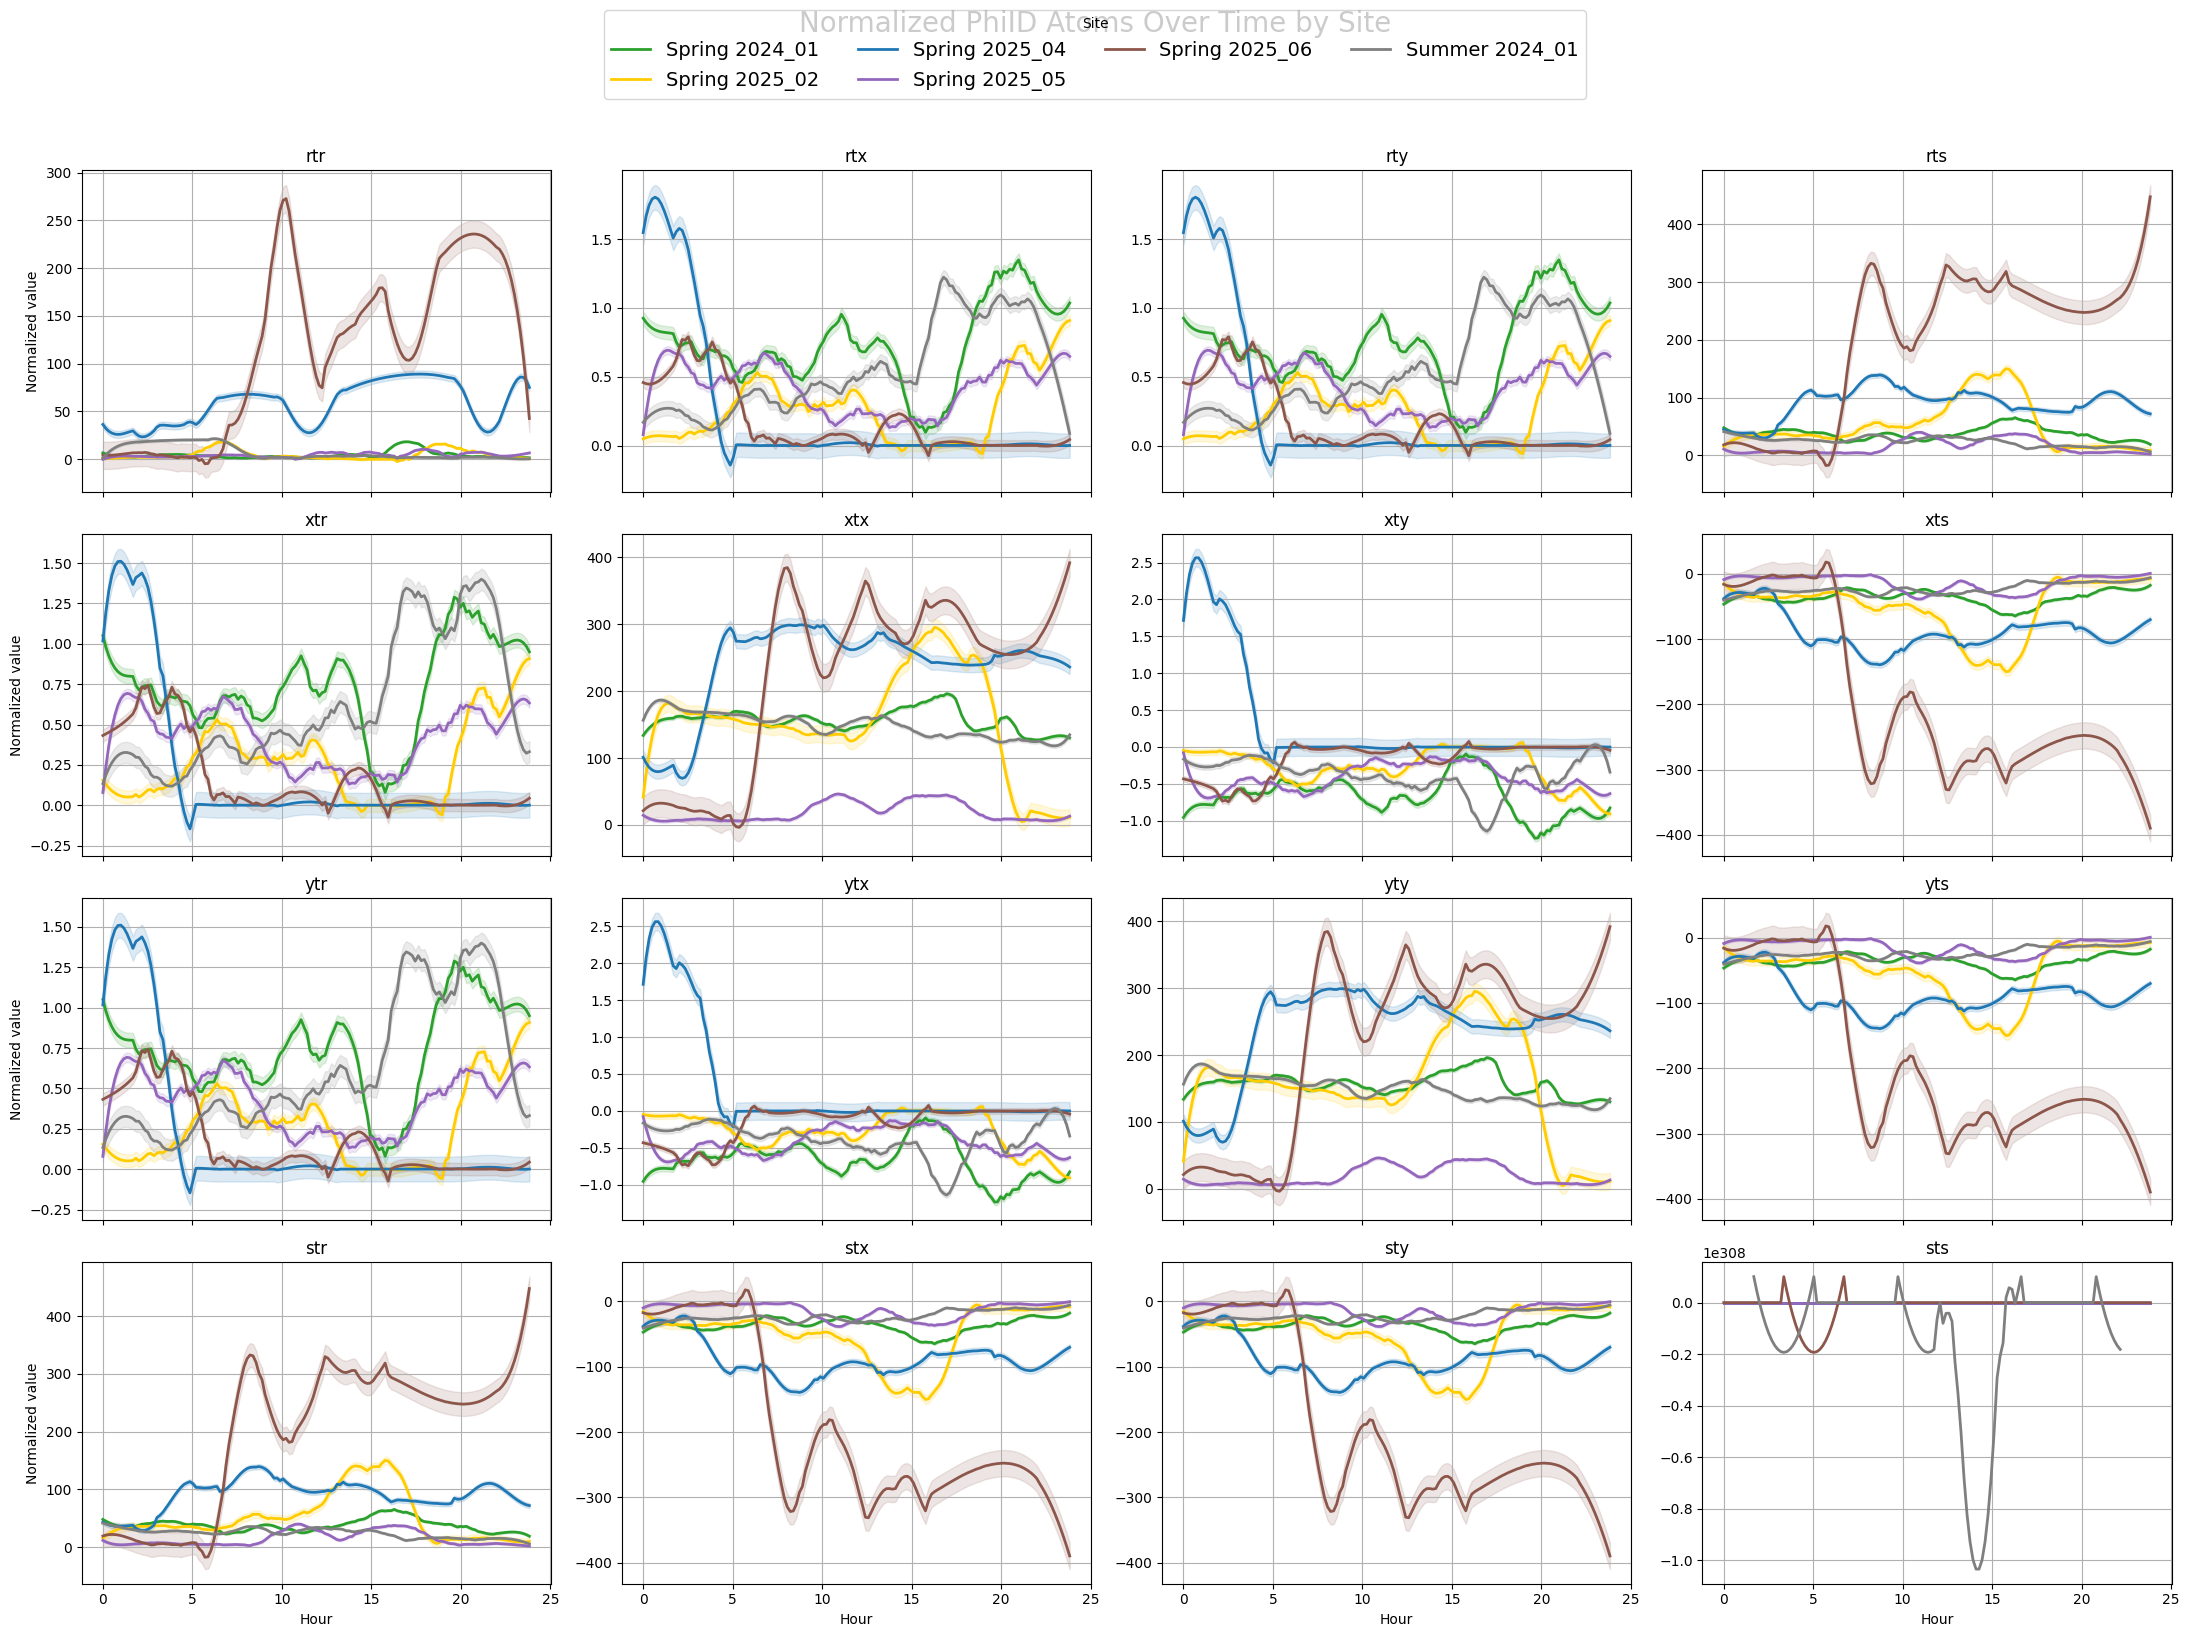

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# List all 16 atom names in the order of your columns
atom_names = [
    "rtr", "rtx", "rty", "rts",
    "xtr", "xtx", "xty", "xts",
    "ytr", "ytx", "yty", "yts",
    "str", "stx", "sty", "sts"
]

# 1) Ensure Hour column exists (global 0–24)
total_epochs = df_all_sites_combined["Epoch"].max() + 1
df_all_sites_combined["Hour"] = df_all_sites_combined["Epoch"] / total_epochs * 24

# 2) Compute N_max = P*(P-1)
plants = np.union1d(df_all_sites_combined["Plant1"].unique(),
                    df_all_sites_combined["Plant2"].unique())
N_max = len(plants) * (len(plants) - 1)

# 3) Extract and order site names (keep dict insertion order)
site_names = list(sites.values())
site_order = site_names  # or sorted(site_names) if you prefer alphabetical

# 4) Use your site color map
color_map = site_colors.copy()

# 5) Plot all atoms (one subplot per atom)
fig, axes = plt.subplots(4, 4, figsize=(22, 16), sharex=True)
axes = axes.flatten()

for i, atom in enumerate(atom_names):
    ax = axes[i]
    for site in site_order:
        sub = df_all_sites_combined[df_all_sites_combined["Site_mapped"] == site]
        if sub.empty:
            continue

        # Group by Epoch, average atom across pairs, then scale to N_max
        sum_atom   = sub.groupby("Epoch")[atom].sum()
        count_atom = sub.groupby("Epoch")[atom].count()
        normalized_atom = (sum_atom / count_atom) * N_max

        # Clean up NaNs, smooth only if enough points
        norm_vals = normalized_atom.values
        mask = ~np.isnan(norm_vals)
        if mask.sum() < 7:
            continue
        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum() - 1)
        if window < 5:
            window = 5
        smoothed = savgol_filter(np.nan_to_num(norm_vals), window_length=window, polyorder=3)

        ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
        lower = smoothed - ci
        upper = smoothed + ci
        hours = normalized_atom.index / total_epochs * 24

        ax.plot(hours, smoothed,
                color=color_map[site],
                linewidth=2,
                label=site if i == 0 else None)
        ax.fill_between(hours, lower, upper,
                        color=color_map[site],
                        alpha=0.15)

    ax.set_title(atom)
    ax.grid(True)
    if i % 4 == 0:
        ax.set_ylabel("Normalized value")
    if i >= 12:
        ax.set_xlabel("Hour")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, title="Site")
fig.suptitle("Normalized PhiID Atoms Over Time by Site", fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [8]:
information_dynamics_metrics = {
    "Storage": ["rtr", "xtx", "yty", "sts"],
    "Copy": ["xtx", "yty"],
    "Transfer": ["xty", "ytx"],
    "Erasure": ["rtx", "rty"],
    "Downward causation": ["sty", "stx", "str"],
    "Upward causation": ["xts", "yts", "rts"],
}

IIT_metrics = {
    "Information storage": ["xtx", "yty", "rtr", "sts"],
    "Transfer entropy": ["xty", "xtr", "str", "sty"],
    "Causal density": ["xtr", "ytr", "sty", "str", "str", "xty", "ytx", "stx"],  # note: 'str' appears twice
    "Integrated information": ["rts", "xts", "sts", "sty", "str", "yts", "ytx", "stx", "xty"],
}

import numpy as np

def compute_aggregate_metrics(df, metric_dict):
    """
    Adds columns for each high-level metric in metric_dict,
    summing atom components (skipping NaNs) and cleaning up
    infinities before aggregation. For "Integrated information",
    subtracts 'rtr' from the sum.
    """
    df = df.copy()
    # Clean all referenced atom cols
    all_atom_cols = set(sum(metric_dict.values(), []))
    for col in all_atom_cols:
        if col in df.columns:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    # Aggregate
    for met, atoms in metric_dict.items():
        atoms_present = [a for a in atoms if a in df.columns]
        metric_sum = df[atoms_present].sum(axis=1, skipna=True)
        all_nan = df[atoms_present].isna().all(axis=1)
        metric_sum[all_nan] = np.nan

        if met.lower() == "integrated information" and "rtr" in df.columns:
            metric_sum = metric_sum - df["rtr"]
            metric_sum[metric_sum.isna() | df["rtr"].isna()] = np.nan

        df[met] = metric_sum

    return df


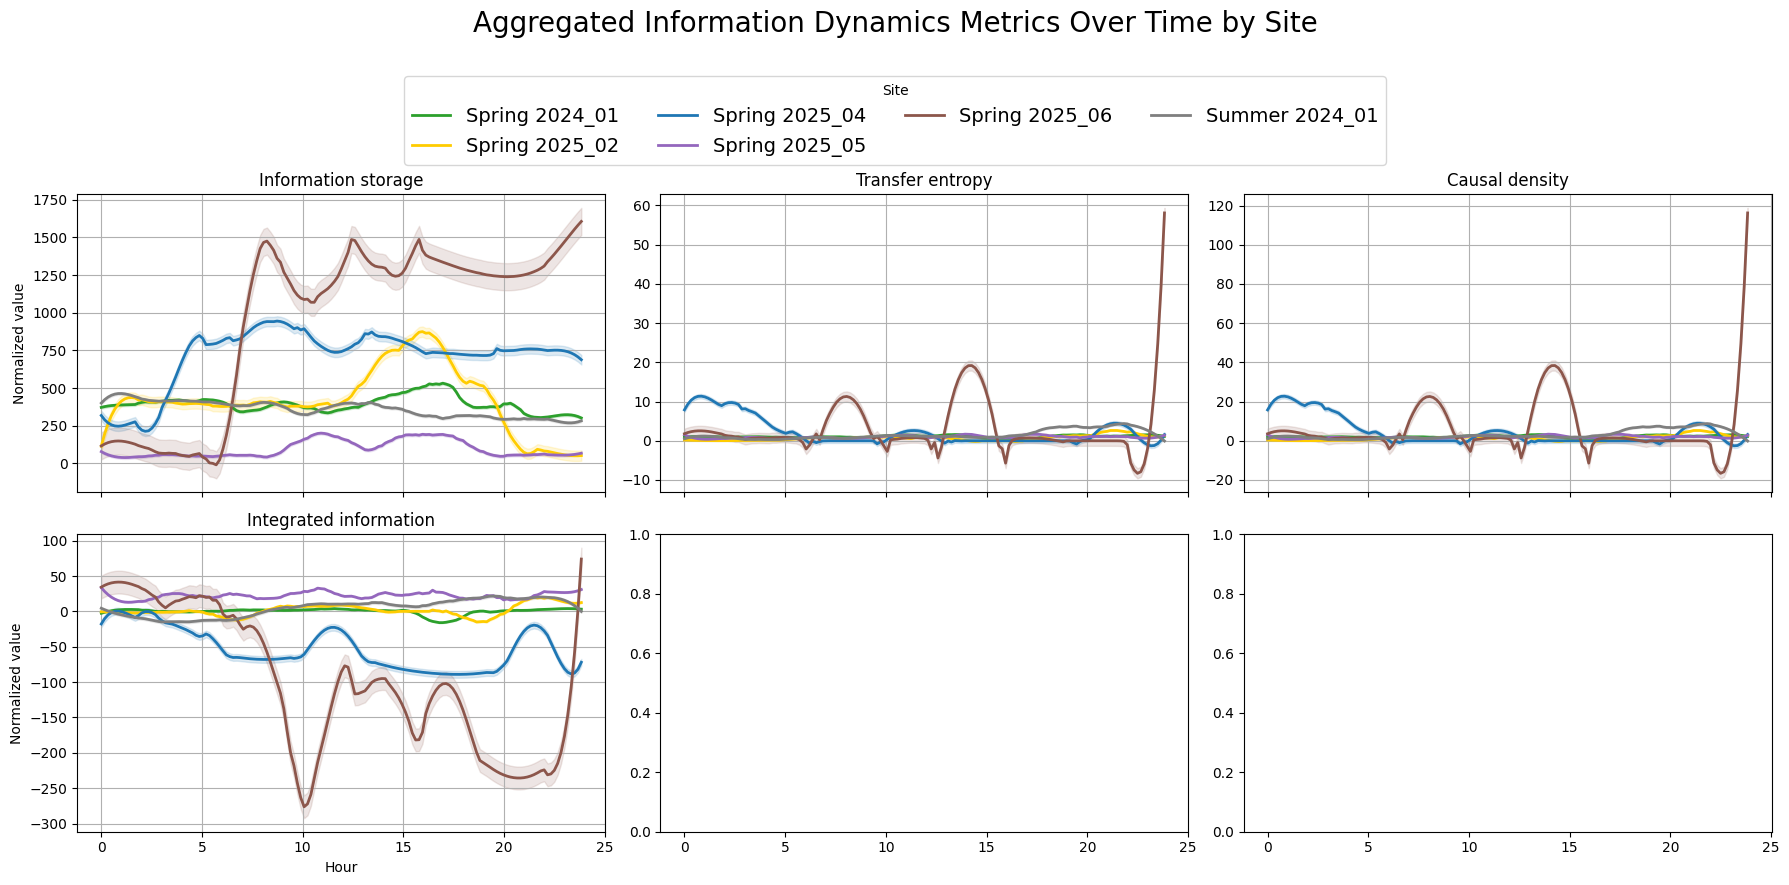

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Choose which metric set to plot
metric_dict = IIT_metrics
metric_names = list(metric_dict.keys())

# Work on sites
df_atoms = df_all_sites_combined
df_metrics = compute_aggregate_metrics(df_atoms, metric_dict)

# N_max and epochs
plants = np.union1d(df_metrics["Plant1"].unique(), df_metrics["Plant2"].unique())
N_max = len(plants) * (len(plants) - 1)
total_epochs = df_metrics["Epoch"].max() + 1

# Order and colors
site_names = list(sites.values())
site_order = site_names  # or sorted(site_names)
color_map = site_colors.copy()

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    ax = axes[i]
    for site in site_order:
        sub = df_metrics[df_metrics["Site_mapped"] == site]
        if sub.empty:
            continue

        sum_val   = sub.groupby("Epoch")[metric].sum()
        count_val = sub.groupby("Epoch")[metric].count()
        normalized = (sum_val / count_val) * N_max

        # Smooth if enough points
        vals = normalized.values
        mask = ~np.isnan(vals)
        if mask.sum() < 7:
            continue
        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum() - 1)
        if window < 5:
            window = 5
        smoothed = savgol_filter(np.nan_to_num(vals), window_length=window, polyorder=3)

        ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
        lower = smoothed - ci
        upper = smoothed + ci
        hours = normalized.index / total_epochs * 24

        ax.plot(hours, smoothed, color=color_map[site], linewidth=2, label=site if i == 0 else None)
        ax.fill_between(hours, lower, upper, color=color_map[site], alpha=0.15)

    ax.set_title(metric)
    ax.grid(True)
    if i % 3 == 0:
        ax.set_ylabel("Normalized value")
    if i >= 3:
        ax.set_xlabel("Hour")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, title="Site", bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Aggregated Information Dynamics Metrics Over Time by Site", fontsize=20, y=1.1)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


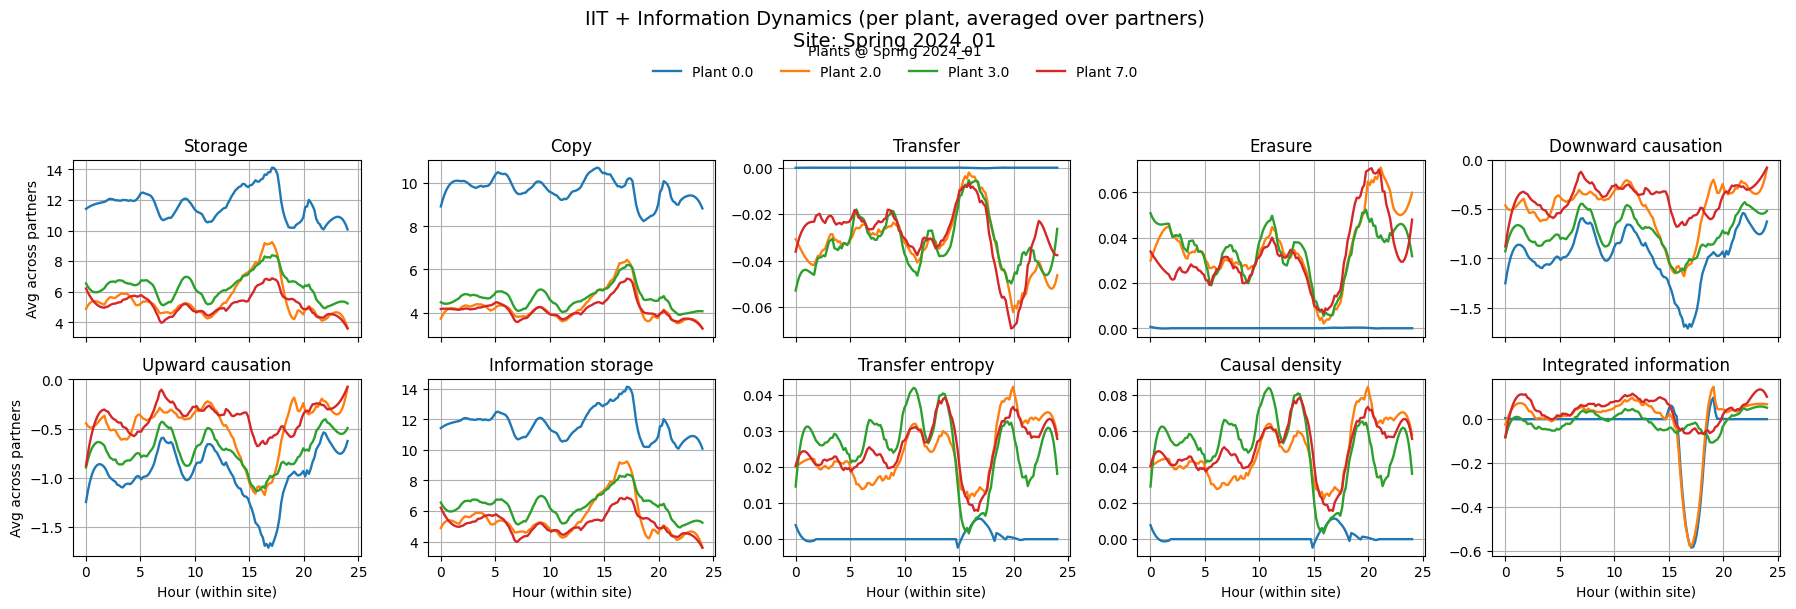

In [10]:
# Combine both sets (names are distinct so no collisions)
combined_metric_dict = {**information_dynamics_metrics, **IIT_metrics}
metric_names = list(combined_metric_dict.keys())

# ----------------- Helper: per-plant mean across partners -----------------
def per_plant_partner_mean(df_site, metric, dedup_pairs=True, return_sem=True):
    """
    For a given site DataFrame and a metric column, compute:
      - For each epoch and unordered pair, the pair's mean metric (dedup (i,j)/(j,i)).
      - Assign that pair value to both plants in the pair.
      - For each (epoch, plant), average across its partners.
    Returns a DataFrame with columns: Epoch, Plant, mean, (optional) sem, n_pairs
    """
    cols = ["Epoch", "Plant1", "Plant2", metric]
    sub = df_site[cols].dropna(subset=[metric]).copy()
    if sub.empty:
        return pd.DataFrame(columns=["Epoch", "Plant", "mean", "sem", "n_pairs"])

    if dedup_pairs:
        # collapse direction by unordered pair within each epoch
        sub["pair_key"] = sub.apply(lambda r: tuple(sorted((r["Plant1"], r["Plant2"]))), axis=1)
        pair_vals = (
            sub.groupby(["Epoch", "pair_key"], as_index=False)[metric]
               .mean()  # average (i,j)/(j,i) if both exist
               .rename(columns={metric: "pair_val"})
        )
        # explode to per-plant rows
        pair_vals["Plant"] = pair_vals["pair_key"].apply(lambda t: [t[0], t[1]])
        exploded = pair_vals.explode("Plant", ignore_index=True)
        # now average across the (epoch, plant)'s partner set
        g = exploded.groupby(["Epoch", "Plant"])["pair_val"]
    else:
        # simpler: count both directions separately
        a = sub[["Epoch", "Plant1", metric]].rename(columns={"Plant1": "Plant", metric: "pair_val"})
        b = sub[["Epoch", "Plant2", metric]].rename(columns={"Plant2": "Plant", metric: "pair_val"})
        both = pd.concat([a, b], ignore_index=True)
        g = both.groupby(["Epoch", "Plant"])["pair_val"]

    out = g.agg(["mean", "std", "count"]).reset_index().rename(
        columns={"std": "std_pairs", "count": "n_pairs"}
    )
    if return_sem:
        out["sem"] = out["std_pairs"] / np.sqrt(out["n_pairs"]).replace(0, np.nan)
    else:
        out["sem"] = np.nan
    return out[["Epoch", "Plant", "mean", "sem", "n_pairs"]]

# ----------------- Pick the site to plot -----------------
# You can set by code: site_to_plot = sites["SPRING2"]
# or directly by the mapped/folder label:
site_to_plot = list(sites.values())[0]  # e.g., "Spring 2024_01" acting as a 'site' label

# Filter to the site and add aggregated metric columns
df_site_atoms = df_all_sites_combined[df_all_sites_combined["Site_mapped"] == site_to_plot].copy()
df_site_metrics = df_site_atoms.copy()

# Clean/compute aggregated metrics (sums of atoms, special handling for Integrated information)
df_site_metrics = compute_aggregate_metrics(df_site_metrics, combined_metric_dict)

# Prepare hours within this site (0–24)
if len(df_site_metrics) == 0:
    raise ValueError(f"No data for site '{site_to_plot}'.")
site_epochs_max = df_site_metrics["Epoch"].max()
site_epoch_den = max(1, site_epochs_max)  # avoid 0 division if only epoch==0
# We'll compute hours from grouped indices later to keep alignment

# Plants present in this site (labels as in Plant1/Plant2)
plants_in_site = np.union1d(df_site_metrics["Plant1"].unique(), df_site_metrics["Plant2"].unique())

# ----------------- Plot: 2 rows x 5 columns (10 metrics total) -----------------
n_metrics = len(metric_names)
ncols = 5
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.6*ncols, 2.8*nrows), sharex=True)
if nrows == 1:
    axes = np.array([axes])
axes = axes.flatten()

# color cycle per-plant (let matplotlib handle it)
for i, metric in enumerate(metric_names):
    ax = axes[i]
    # compute per-plant partner-mean time series for this metric
    df_pp = per_plant_partner_mean(df_site_metrics, metric, dedup_pairs=True, return_sem=True)
    if df_pp.empty:
        ax.set_title(metric)
        ax.grid(True)
        continue

    # plot each plant curve
    for plant in plants_in_site:
        cur = df_pp[df_pp["Plant"] == plant].sort_values("Epoch")
        if cur.empty:
            continue

        # Smooth only if enough points
        y = cur["mean"].values.astype(float)
        x_epochs = cur["Epoch"].values.astype(float)
        hours = x_epochs / site_epoch_den * 24.0

        if np.isfinite(y).sum() >= 7:
            # choose odd window <= number of finite points, min 5
            n_fin = int(np.isfinite(y).sum())
            win = min(21, n_fin if n_fin % 2 == 1 else n_fin - 1)
            win = max(win, 5)
            y_smooth = savgol_filter(np.nan_to_num(y, nan=np.nanmean(y) if np.isfinite(y).any() else 0.0),
                                     window_length=win, polyorder=3)
        else:
            y_smooth = y

        ax.plot(hours, y_smooth, linewidth=1.7, label=f"Plant {plant}")

        # Optional: partner-SEM band
        # sem = cur["sem"].values.astype(float)
        # if len(sem) == len(y_smooth) and np.isfinite(sem).any():
        #     ax.fill_between(hours, y_smooth - sem, y_smooth + sem, alpha=0.12)

    ax.set_title(metric)
    ax.grid(True)
    if i % ncols == 0:
        ax.set_ylabel("Avg across partners")
    if i // ncols == nrows - 1:
        ax.set_xlabel("Hour (within site)")

# Clean up extra axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# One legend outside
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=min(len(plants_in_site), 6),
               fontsize=10, title=f"Plants @ {site_to_plot}", frameon=False, bbox_to_anchor=(0.5, 1.04))

fig.suptitle(f"IIT + Information Dynamics (per plant, averaged over partners)\nSite: {site_to_plot}",
             fontsize=14, y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()